# 17.2.2 连续伴随与公平外推基线

## 学习目标与先修知识

在同一二维螺旋观测（observation）上核对伴随梯度（gradient）、数值精度和机制基线。

先修：17.1.2 原任务边界；15.3 伴随方程。

## 具体问题

训练点上的损失下降，能否证明神经向量场（vector field）优于简单线性螺旋机制？

In [1]:
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先计算一个可手算的数值，再提出本节需要核验的主张。

In [2]:
print("观测时刻：",np.arange(0,101,5)*.02)

观测时刻： [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2. ]


## 模型假设

课程缩减任务：一条二维带固定噪声的训练螺旋，观测点每三步采样（sampling）；独立初态与训练末端之后的时刻只用于评价。四参数（parameter） tanh 向量场在 c=d=0 时退化为解析机制基线。采用固定 RK4 网格计算轨迹（trajectory），再反向积分连续伴随来更新四个参数。

## 数学解释与推导

对 $f=(-ax-\omega y+c\tanh x,\omega x-ay+d\tanh y)$，需分别计算 $J_z=\partial_z f$ 和 $J_\theta=\partial_\theta f$。反向积分 $\dot\lambda=-J_z^\mathsf T\lambda$、$\dot g=-J_\theta^\mathsf T\lambda$；越过观测时间使 $\lambda^- =\lambda^+ +(z-y)/m$。有限差分（finite difference）梯度是独立数值参考；两者都可能受步长误差影响。训练与外推必须用相同观测预算评价，机制基线不读取测试真值。

## 核心实现

以下短函数展示方程、数值步骤和可修改的计算顺序。

In [3]:
def spiral_rhs(state, parameters):
    """Four-parameter tanh vector field; linear damped spiral when c=d=0."""
    x,y=np.asarray(state,dtype=float);a,omega,c,d=parameters
    return np.array([-a*x-omega*y+c*np.tanh(x),omega*x-a*y+d*np.tanh(y)])


def spiral_state_jacobian(state, parameters):
    x,y=np.asarray(state,dtype=float);a,omega,c,d=parameters
    return np.array([[-a+c*(1-np.tanh(x)**2),-omega],
                     [omega,-a+d*(1-np.tanh(y)**2)]])


def spiral_parameter_jacobian(state, parameters):
    x,y=np.asarray(state,dtype=float)
    return np.array([[-x,-y,np.tanh(x),0.],[-y,x,0.,np.tanh(y)]])


def spiral_exact(initial,a,omega,times):
    initial=np.asarray(initial,dtype=float);times=np.asarray(times,dtype=float)
    theta=omega*times;factor=np.exp(-a*times)
    return np.column_stack([factor*(initial[0]*np.cos(theta)-initial[1]*np.sin(theta)),
                            factor*(initial[0]*np.sin(theta)+initial[1]*np.cos(theta))])


def rk4_path(rhs, initial, h, steps):
    state=np.asarray(initial,dtype=float)
    rows=[state.copy()]
    for _ in range(steps):
        k1=np.asarray(rhs(state));k2=np.asarray(rhs(state+h*k1/2))
        k3=np.asarray(rhs(state+h*k2/2));k4=np.asarray(rhs(state+h*k3))
        state=state+h*(k1+2*k2+2*k3+k4)/6
        rows.append(state.copy())
    return np.asarray(rows)


def rk4_spiral(initial,parameters,h,steps):
    return rk4_path(lambda state:spiral_rhs(state,parameters),initial,h,steps)


def adjoint_spiral(initial,parameters,h,observed_indices,targets):
    """Continuous adjoint integrated backward on a fixed RK4 grid; observations jump lambda."""
    path=rk4_spiral(initial,parameters,h,max(observed_indices))
    indices=np.asarray(observed_indices,dtype=int)
    targets=np.asarray(targets,dtype=float)
    residual=path[indices]-targets
    loss=float(np.mean(np.sum(residual*residual,axis=1))/2)
    jump={int(index):residual[j]/len(indices) for j,index in enumerate(indices)}
    lam=np.zeros(2);gradient=np.zeros(4)
    for step in range(len(path)-1,-1,-1):
        if step in jump:lam=lam+jump[step]
        if step==0:break
        z0,z1=path[step],path[step-1];middle=(z0+z1)/2
        def derivative(vec,state):
            l=vec[:2]
            return np.r_[-spiral_state_jacobian(state,parameters).T@l,
                         -spiral_parameter_jacobian(state,parameters).T@l]
        value=np.r_[lam,gradient];dt=-h
        k1=derivative(value,z0);k2=derivative(value+dt*k1/2,middle)
        k3=derivative(value+dt*k2/2,middle);k4=derivative(value+dt*k3,z1)
        value=value+dt*(k1+2*k2+2*k3+k4)/6
        lam,gradient=value[:2],value[2:]
    return loss,gradient,path

## 对照实验

先用中心差分（central difference）核对伴随梯度，再用同一组观测拟合四参数向量场和机制基线，比较新初态上的预测。

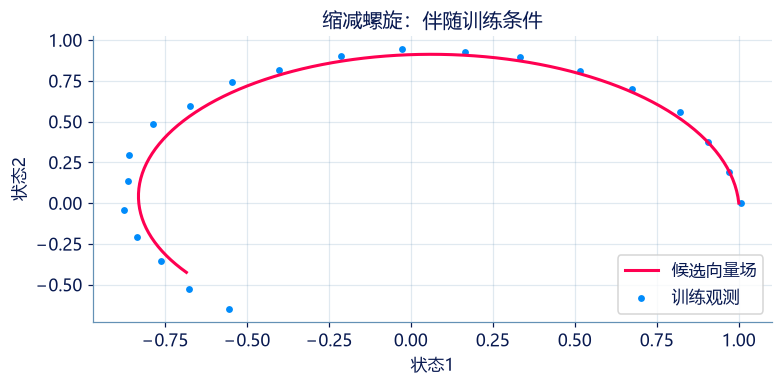

损失 0.012347669032913537 伴随 [ 0.01044287 -0.15441243  0.00798361 -0.01758764] 独立差分 [0.01044613531613059, -0.15442981914550596, 0.007983339576564386, -0.017590044045553282]


C:\Users\10149\AppData\Local\Temp\ipykernel_69160\547734573.py:32: UserWarning: The figure layout has changed to tight
  axes[1].legend();fig.tight_layout();plt.show()


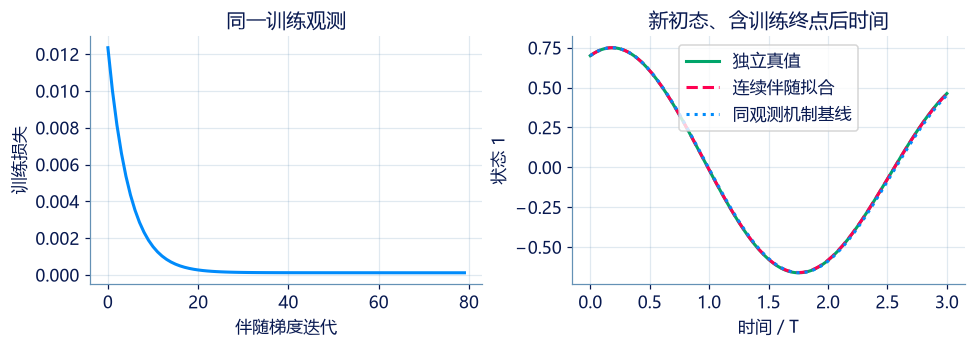

初/末训练损失 0.012347669032913537 0.00011463888474857767 ；外推 RMSE：课程向量场 0.0012480783698355009 机制基线 0.007178650401019948
拟合参数 [0.08974975 2.00011695 0.01269128 0.00519707] ；同观测基线参数 [0.0800654  1.99081562]


In [4]:
h=.02;indices=np.arange(0,101,5);times=indices*h;clean=spiral_exact([1.,0.],.08,2.,times);noise=np.random.default_rng(1806).normal(0,.01,clean.shape);observed=clean+noise;theta=np.array([.11,1.85,.02,-.02])
loss,gradient,path=adjoint_spiral([1.,0.],theta,h,indices,observed);delta=1e-5;fd=[]
for j in range(4):
    shift=np.zeros(4);shift[j]=delta
    fd.append((adjoint_spiral([1.,0.],theta+shift,h,indices,observed)[0]-adjoint_spiral([1.,0.],theta-shift,h,indices,observed)[0])/(2*delta))
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(path[:,0],path[:,1],label="候选向量场",color=PINK);ax.scatter(observed[:,0],observed[:,1],s=12,label="训练观测",color=BLUE);ax.set(xlabel="状态1",ylabel="状态2",title="缩减螺旋：伴随训练条件");ax.legend();ax.grid(alpha=.2);plt.show()
print("损失",loss,"伴随",gradient,"独立差分",fd)
initial_loss=loss;theta=np.array([.11,1.85,.02,-.02])
loss_history=[]
for iteration in range(80):
    current,grad,_=adjoint_spiral([1.,0.],theta,h,indices,observed)
    loss_history.append(current)
    theta-=.1*grad
final_loss,_,_=adjoint_spiral([1.,0.],theta,h,indices,observed)
dt=5*h;rows=[];targets=[]
for (x,y),(dx,dy) in zip(observed[1:-1],(observed[2:]-observed[:-2])/(2*dt)):
    rows.extend([[-x,-y],[-y,x]])
    targets.extend([dx,dy])
baseline_parameters=np.linalg.lstsq(rows,targets,rcond=None)[0]
test_times=np.arange(151)*h
independent_truth=spiral_exact([.7,-.3],.08,2.,test_times)
learned=rk4_spiral([.7,-.3],theta,h,150)
baseline=rk4_spiral([.7,-.3],[*baseline_parameters,0.,0.],h,150)
learned_rmse=float(np.sqrt(np.mean((learned-independent_truth)**2)))
baseline_rmse=float(np.sqrt(np.mean((baseline-independent_truth)**2)))
fig,axes=plt.subplots(1,2,figsize=(9,3.3))
axes[0].plot(loss_history,color=BLUE);axes[0].set(xlabel="伴随梯度迭代",ylabel="训练损失",title="同一训练观测")
axes[1].plot(test_times,independent_truth[:,0],label="独立真值",color=GREEN)
axes[1].plot(test_times,learned[:,0],"--",label="连续伴随拟合",color=PINK)
axes[1].plot(test_times,baseline[:,0],":",label="同观测机制基线",color=BLUE)
axes[1].set(xlabel="时间 / T",ylabel="状态 1",title="新初态、含训练终点后时间")
axes[1].legend();fig.tight_layout();plt.show()
print("初/末训练损失",initial_loss,final_loss,"；外推 RMSE：课程向量场",learned_rmse,"机制基线",baseline_rmse)
print("拟合参数",theta,"；同观测基线参数",baseline_parameters)


## 结果解释

伴随训练损失下降，独立初态及训练终点之后的测试窗也给出可报告误差；机制基线仅用同一训练观测估参。比较两者在新初态和外推时间窗中的误差，可以观察增加非线性修正后预测怎样变化。

### 独立核对

将伴随梯度与中心差分比较；用解析螺旋核对线性机制基线，并检查新初态上的预测误差。

In [5]:
np.testing.assert_allclose(gradient,fd,rtol=.025,atol=.003)
assert final_loss<initial_loss and learned_rmse<.05 and baseline_rmse<.05
assert len(rows)==2*(len(observed)-2) and len(targets)==len(rows)
np.testing.assert_allclose(rk4_spiral([.7,-.3],[.08,2.,0.,0.],h,150),independent_truth,atol=1e-5)
print("梯度、训练下降、同观测基线和独立解析轨迹通过。")

梯度、训练下降、同观测基线和独立解析轨迹通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/17-02-%E5%A4%8D%E7%8E%B0%E5%8D%8F%E8%AE%AE%E4%B8%8E%E5%85%AC%E5%B9%B3%E5%9F%BA%E7%BA%BF/explore/)。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：基线信息公平

候选与机制基线比较，什么做法公平？

- **A.** 机制基线读取测试真值
- **B.** 候选读取额外测试时间
- **C.** 同一训练观测（observation）和独立测试初态
- **D.** 只报告候选训练损失

[作答：基线信息公平](http://127.0.0.1:8000/chapters/17-02-%E5%A4%8D%E7%8E%B0%E5%8D%8F%E8%AE%AE%E4%B8%8E%E5%85%AC%E5%B9%B3%E5%9F%BA%E7%BA%BF/practice/?question=p17-c2s2-choice1)

### 第 2 题 · 单项选择题：梯度核验

连续伴随实现和中心差分（central difference）相近，能够直接证明什么？

- **A.** 原论文性能已复现
- **B.** 对任何求解精度都无误
- **C.** 在当前数值条件下梯度（gradient）方向被独立核对
- **D.** 神经场比机制基线更优

[作答：梯度核验](http://127.0.0.1:8000/chapters/17-02-%E5%A4%8D%E7%8E%B0%E5%8D%8F%E8%AE%AE%E4%B8%8E%E5%85%AC%E5%B9%B3%E5%9F%BA%E7%BA%BF/practice/?question=p17-c2s2-choice2)

### 第 3 题 · Python 计算题：伴随状态 Jacobian

训练点上的损失下降，能否证明神经向量场（vector field）优于简单线性螺旋机制？本题计算“伴随状态（state） Jacobian”：对 f 的 x、y 分别求导；tanh 的导数（derivative）为 1-tanh²。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    state: list[float],
    parameters: list[float],
) -> list[list[float]]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[float]` | 二维状态。 | 1 |
| `parameters` | `list[float]` | a、omega、c、d。 | 1/T |

**返回值**

直接返回 jacobian（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `jacobian` | `list[list[float]]` | 对状态的 2×2 Jacobian。 | 1/T |

**计算规则**

对 f 的 x、y 分别求导；tanh 的导数为 1-tanh²。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 二维状态。 | [0.0, 0.0] | 1 |
| parameters | a、omega、c、d。 | [0.1, 2.0, 0.3, 0.4] | 1/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [0.0, 0.0]
parameters = [0.1, 2.0, 0.3, 0.4]

result = solve(state, parameters)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| jacobian | 对状态的 2×2 Jacobian。 | [[0.19999999999999998, -2.0], [2.0, 0.30000000000000004]] | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.19999999999999998, -2.0],
                   [2.0, 0.30000000000000004]]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；对 f 的 x、y 分别求导；tanh 的导数为 1-tanh²。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：伴随状态 Jacobian](http://127.0.0.1:8000/chapters/17-02-%E5%A4%8D%E7%8E%B0%E5%8D%8F%E8%AE%AE%E4%B8%8E%E5%85%AC%E5%B9%B3%E5%9F%BA%E7%BA%BF/practice/?question=p17-state-jacobian)

### 第 4 题 · Python 计算题：伴随参数 Jacobian

训练点上的损失下降，能否证明神经向量场（vector field）优于简单线性螺旋机制？本题计算“伴随参数（parameter） Jacobian”：两行依次为 [-x,-y,tanh(x),0]、[-y,x,0,tanh(y)]。请按下方具名参数和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    state: list[float],
    parameters: list[float],
) -> list[list[float]]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[float]` | 二维状态（state）。 | 1 |
| `parameters` | `list[float]` | a、omega、c、d；该式的导数（derivative）不显含这些值。 | 1/T |

**返回值**

直接返回 jacobian（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `jacobian` | `list[list[float]]` | 对四参数的 2×4 Jacobian。 | 1 |

**计算规则**

两行依次为 [-x,-y,tanh(x),0]、[-y,x,0,tanh(y)]。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 二维状态（state）。 | [1.0, 0.0] | 1 |
| parameters | a、omega、c、d；该式的导数（derivative）不显含这些值。 | [0.1, 2.0, 0.0, 0.0] | 1/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [1.0, 0.0]
parameters = [0.1, 2.0, 0.0, 0.0]

result = solve(state, parameters)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| jacobian | 对四参数的 2×4 Jacobian。 | [[-1.0, -0.0, 0.7615941559557649, 0.0], [-0.0, 1.0, 0.0, 0.0]] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[-1.0, -0.0, 0.7615941559557649, 0.0],
                   [-0.0, 1.0, 0.0, 0.0]]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；两行依次为 [-x,-y,tanh(x),0]、[-y,x,0,tanh(y)]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：伴随参数 Jacobian](http://127.0.0.1:8000/chapters/17-02-%E5%A4%8D%E7%8E%B0%E5%8D%8F%E8%AE%AE%E4%B8%8E%E5%85%AC%E5%B9%B3%E5%9F%BA%E7%BA%BF/practice/?question=p17-parameter-jacobian)

**原始参考**

[Chen 等，arXiv:1806.07366v1](https://arxiv.org/abs/1806.07366v1)